In [9]:
# general functions
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import OrderedDict
# visualization
from PIL import Image
# identifying faces
#%pip install mtcnn
from mtcnn.mtcnn import MTCNN
# visualizing bounding boxes
import matplotlib.patches as patches
# CNN
import keras
from sklearn.model_selection import train_test_split
# Moving files between directories
import shutil
from shutil import unpack_archive
from subprocess import check_output

In [11]:
lfw_allnames = pd.read_csv("lfw_allnames.csv")

In [13]:
matchpairsDevTest = pd.read_csv("matchpairsDevTest.csv")
matchpairsDevTrain = pd.read_csv("matchpairsDevTrain.csv")
mismatchpairsDevTest = pd.read_csv("mismatchpairsDevTest.csv")
mismatchpairsDevTrain = pd.read_csv("mismatchpairsDevTrain.csv")
pairs = pd.read_csv("pairs.csv")


In [15]:
pairs = pairs.rename(columns={'name': 'name1', 'Unnamed: 3': 'name2'})
matched_pairs = pairs[pairs["name2"].isnull()].drop("name2", axis=1)
mismatched_pairs = pairs[pairs["name2"].notnull()]
people = pd.read_csv("people.csv")

In [17]:
people = people[people.name.notnull()]
peopleDevTest = pd.read_csv("peopleDevTest.csv")
peopleDevTrain = pd.read_csv("peopleDevTrain.csv")


In [19]:
lfw_allnames.head()

,name,images
0,AJ_Cook,1
1,AJ_Lamas,1
2,Aaron_Eckhart,1
3,Aaron_Guiel,1
4,Aaron_Patterson,1


# Exploratory Data Analysis (EDA)

In [22]:
print("Summary:")
print("There are " + 
      str(lfw_allnames.shape[0]) + 
      " unique celebrities in the entire dataset, of whom " + 
      str(sum(lfw_allnames.images > 1)) + 
      " are represented by multiple images. The entire number of images available is " + 
      str(sum(lfw_allnames.images)) + 
      ". The most represented celebrity is " + 
      str(lfw_allnames.iloc[lfw_allnames['images'].idxmax()][0]) + 
      ", with " + 
      str(max(lfw_allnames.images)) + 
      " unique images in the dataset.")

Summary:
There are 5749 unique celebrities in the entire dataset, of whom 1680 are represented by multiple images. The entire number of images available is 13233. The most represented celebrity is George_W_Bush, with 530 unique images in the dataset.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_12992\170007965.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  str(lfw_allnames.iloc[lfw_allnames['images'].idxmax()][0]) +


In [34]:
# shape data frame so there is a row per image, matched to relevant jpg file
image_paths = lfw_allnames.loc[lfw_allnames.index.repeat(lfw_allnames['images'])]
image_paths['image_path'] = 1 + image_paths.groupby('name').cumcount()
image_paths['image_path'] = image_paths.image_path.apply(lambda x: '{0:0>4}'.format(x))
image_paths['image_path'] = image_paths.name + "/" + image_paths.name + "_" + image_paths.image_path + ".jpg"
image_paths = image_paths.drop("images", axis=1)  # Fixed drop

# Ensure reproducibility by setting a random seed
lfw_train, lfw_test = train_test_split(image_paths, test_size=0.2, random_state=42)

# Reset index and drop it
lfw_train = lfw_train.reset_index().drop("index", axis=1)
lfw_test = lfw_test.reset_index().drop("index", axis=1)

# Verify overlap and mismatch
print(len(set(lfw_train.name).intersection(set(lfw_test.name))))  # Should be 843
print(len(set(lfw_test.name) - set(lfw_train.name)))  # Should be 874


852
863


In [38]:
# Assuming image_paths.image_path contains the relative paths
widths = []
heights = []
files = image_paths.image_path

# Loop through image paths and extract width and height
for file in files:
    path = "lfw-deepfunneled/" + str(file)  # Relative path if working in the same folder
    im = Image.open(path)
    widths.append(im.width)
    heights.append(im.height)

# Creating a DataFrame and summarizing the image dimensions
pd.DataFrame({'height': heights, 'width': widths}).describe()


,height,width
count,13233.0,13233.0
mean,250.0,250.0
std,0.0,0.0
min,250.0,250.0
25%,250.0,250.0
50%,250.0,250.0
75%,250.0,250.0
max,250.0,250.0


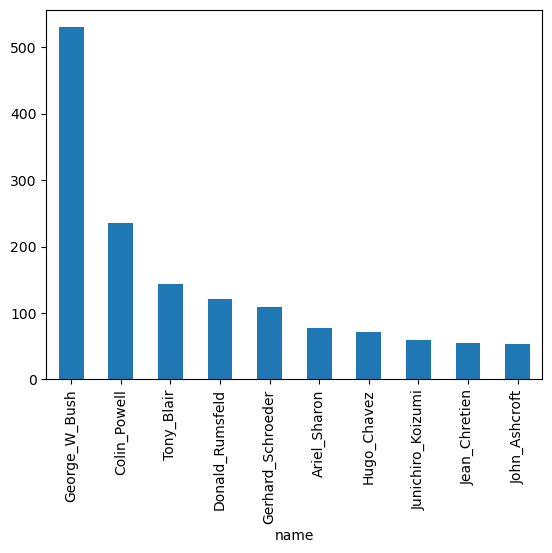

In [40]:
image_paths['name'].value_counts()[:10].plot(kind = "bar")
plt.show()

In [42]:
ind_counts = image_paths.groupby('name').count().image_path
print(str(sum(ind_counts[ind_counts==1])) + " individuals, which is " + str(round(100*(sum(ind_counts[ind_counts==1])/sum(ind_counts)))) + "% of the total individuals considered, are only represented by a single image in this dataset.")

4069 individuals, which is 31% of the total individuals considered, are only represented by a single image in this dataset.


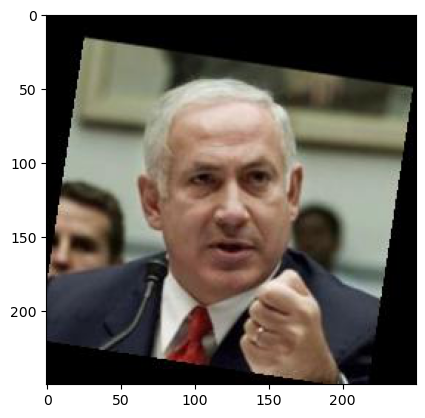

In [44]:
im = Image.open("lfw-deepfunneled/" + str(lfw_train.image_path[0]))  # Use relative path
plt.imshow(im)
plt.show()
